In [19]:
# Ячейка 1: Установка библиотек (если ещё не установлены)
import sys
# Ячейка 1: Импорт библиотек
import pandas as pd
import numpy as np

In [20]:
# Ячейка 2: Загрузка данных
file_old = 'music_old.csv'
file_new = 'music_new.csv'

df_old = pd.read_csv(file_old)
df_new = pd.read_csv(file_new)

columns_to_check = ['loudness', 'popularity', 'danceability', 'energy']

print("Данные загружены")

Данные загружены


In [21]:
# Ячейка 3: Функция для расчета PSI
def calculate_psi(expected, actual, bins=20):
    # Создаем границы бинов на основе референсных данных
    bin_edges = np.percentile(expected, np.linspace(0, 100, bins + 1))
    bin_edges[-1] = bin_edges[-1] + 0.0001
    
    # Считаем количество в каждом бине
    expected_counts, _ = np.histogram(expected, bins=bin_edges)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)
    
    # Переводим в проценты
    expected_percents = expected_counts / len(expected)
    actual_percents = actual_counts / len(actual)
    
    # Защита от нулей
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    
    # Расчет PSI
    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    
    return psi

In [22]:
# Ячейка 4: Расчет PSI для всех фич
print("=" * 60)
print("РЕЗУЛЬТАТЫ ПРОВЕРКИ НА ДРЕЙФ ДАННЫХ")
print("=" * 60)

results = {}

for column in columns_to_check:
    old_data = df_old[column].dropna()
    new_data = df_new[column].dropna()
    
    psi_value = calculate_psi(old_data, new_data, bins=20)
    results[column] = psi_value
    
    # Интерпретация
    if psi_value < 0.1:
        status = "✅ Нет дрейфа"
    elif psi_value < 0.2:
        status = "⚠️ Умеренный дрейф"
    else:
        status = "❌ Сильный дрейф"
    
    print(f"\n{column}:")
    print(f"  PSI = {psi_value:.4f}")
    print(f"  Статус: {status}")

РЕЗУЛЬТАТЫ ПРОВЕРКИ НА ДРЕЙФ ДАННЫХ

loudness:
  PSI = 0.2353
  Статус: ❌ Сильный дрейф

popularity:
  PSI = 0.0005
  Статус: ✅ Нет дрейфа

danceability:
  PSI = 0.0008
  Статус: ✅ Нет дрейфа

energy:
  PSI = 0.0012
  Статус: ✅ Нет дрейфа


In [23]:
# Ячейка 5: Общие выводы
print("\n" + "=" * 60)
print("ВЫВОДЫ:")
print("-" * 40)

features_with_drift = []
features_warning = []
features_no_drift = []

for column, psi in results.items():
    if psi >= 0.2:
        features_with_drift.append(column)
    elif psi >= 0.1:
        features_warning.append(column)
    else:
        features_no_drift.append(column)

if features_with_drift:
    print(f"❌ Сильный дрейф у фич: {', '.join(features_with_drift)}")
if features_warning:
    print(f"⚠️ Умеренный дрейф у фич: {', '.join(features_warning)}")
if features_no_drift:
    print(f"✅ Нет дрейфа у фич: {', '.join(features_no_drift)}")

print("\nИнтерпретация:")
print("- PSI < 0.1: дрейф отсутствует")
print("- 0.1 ≤ PSI < 0.2: умеренный дрейф (стоит обратить внимание)")
print("- PSI ≥ 0.2: сильный дрейф")
print("=" * 60)


ВЫВОДЫ:
----------------------------------------
❌ Сильный дрейф у фич: loudness
✅ Нет дрейфа у фич: popularity, danceability, energy

Интерпретация:
- PSI < 0.1: дрейф отсутствует
- 0.1 ≤ PSI < 0.2: умеренный дрейф (стоит обратить внимание)
- PSI ≥ 0.2: сильный дрейф


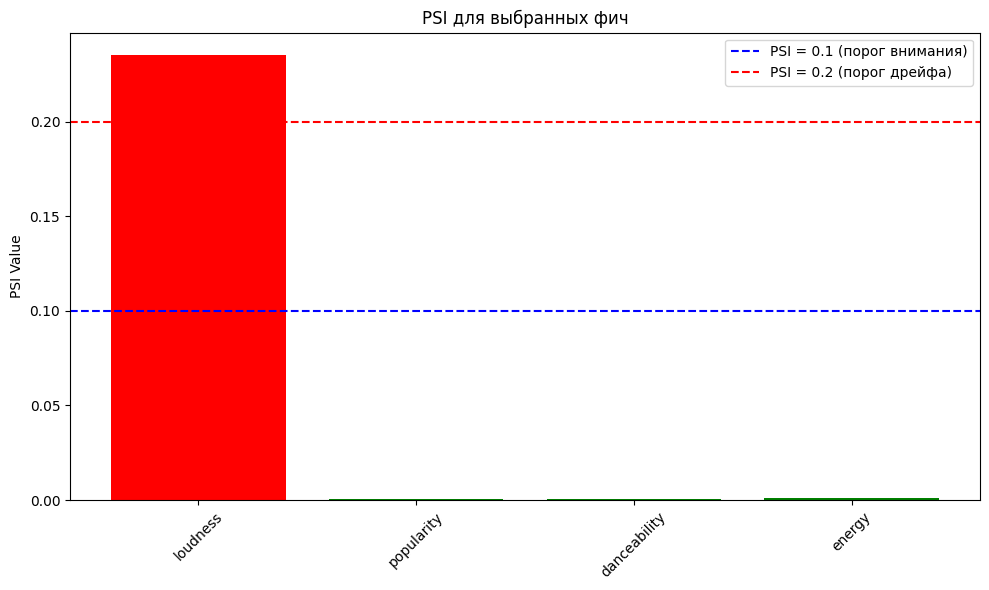

In [24]:
# Ячейка 6: Визуализация (дополнительно)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['green' if x < 0.1 else 'orange' if x < 0.2 else 'red' for x in results.values()]
plt.bar(results.keys(), results.values(), color=colors)
plt.axhline(y=0.1, color='blue', linestyle='--', label='PSI = 0.1 (порог внимания)')
plt.axhline(y=0.2, color='red', linestyle='--', label='PSI = 0.2 (порог дрейфа)')
plt.ylabel('PSI Value')
plt.title('PSI для выбранных фич')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()